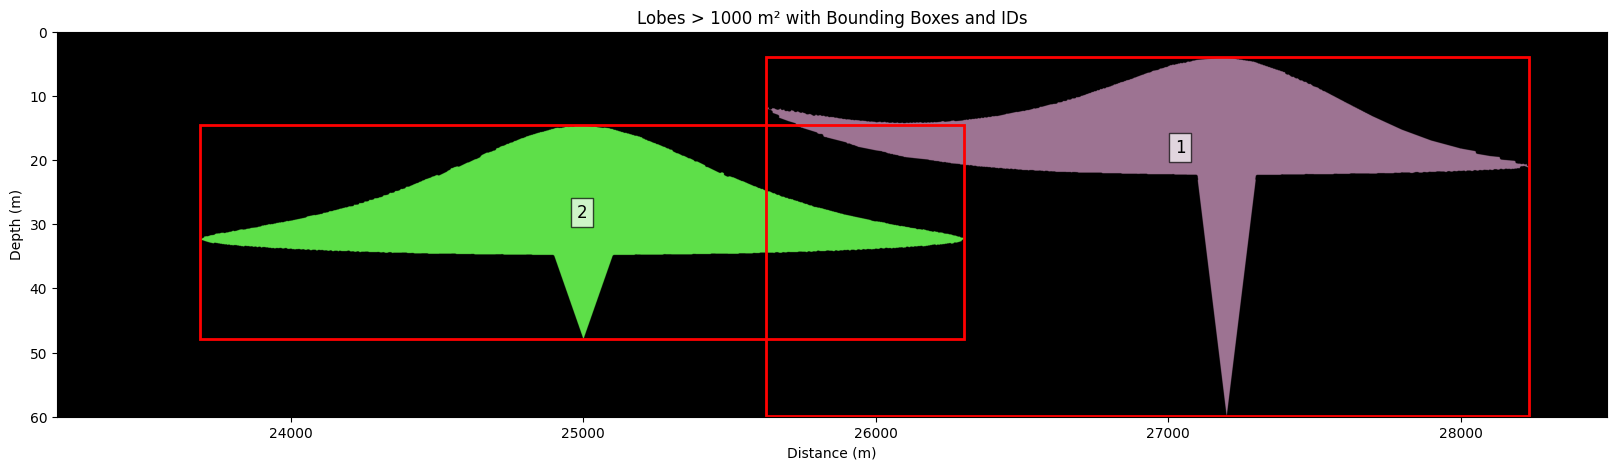

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1  27492.080985  2608.509775   55.846890    27040.564060   
1        2  27694.984713  2611.089478   33.320574    24996.200129   

   Centroid Z (m)  
0       18.087847  
1       28.118886  

Compensation Index (CI): 0.967
Lobe 1 - Average Thickness: 10.54 m
Lobe 2 - Average Thickness: 10.61 m


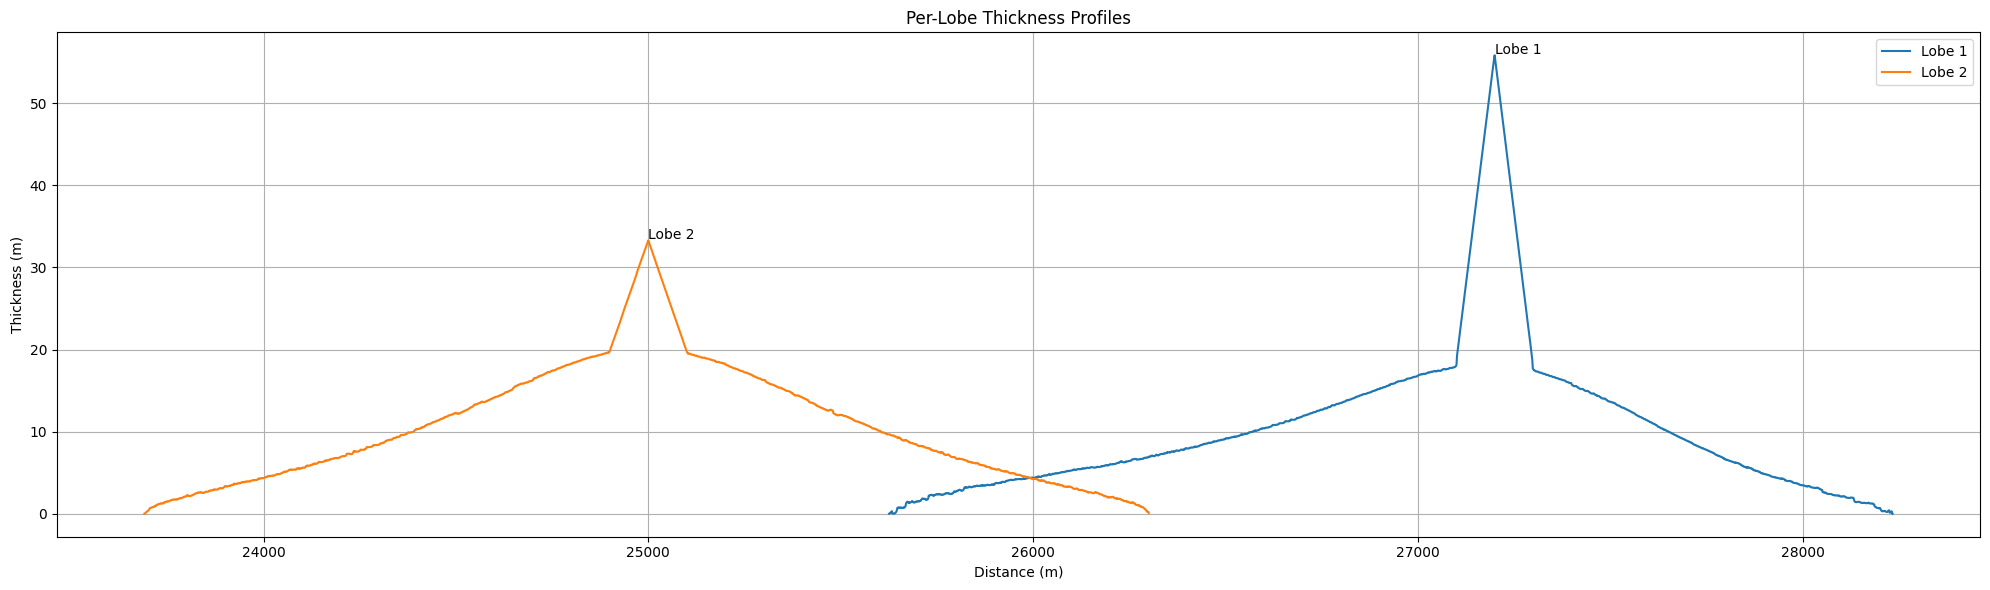

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 28500 - 23200  # 7000 m
real_height_m = 60            # vertical extent in meters
min_area_m2 = 1000            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_coloredFrd20.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 23200 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 23200 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [23200, 28500, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 23200 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(23200, 28500, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



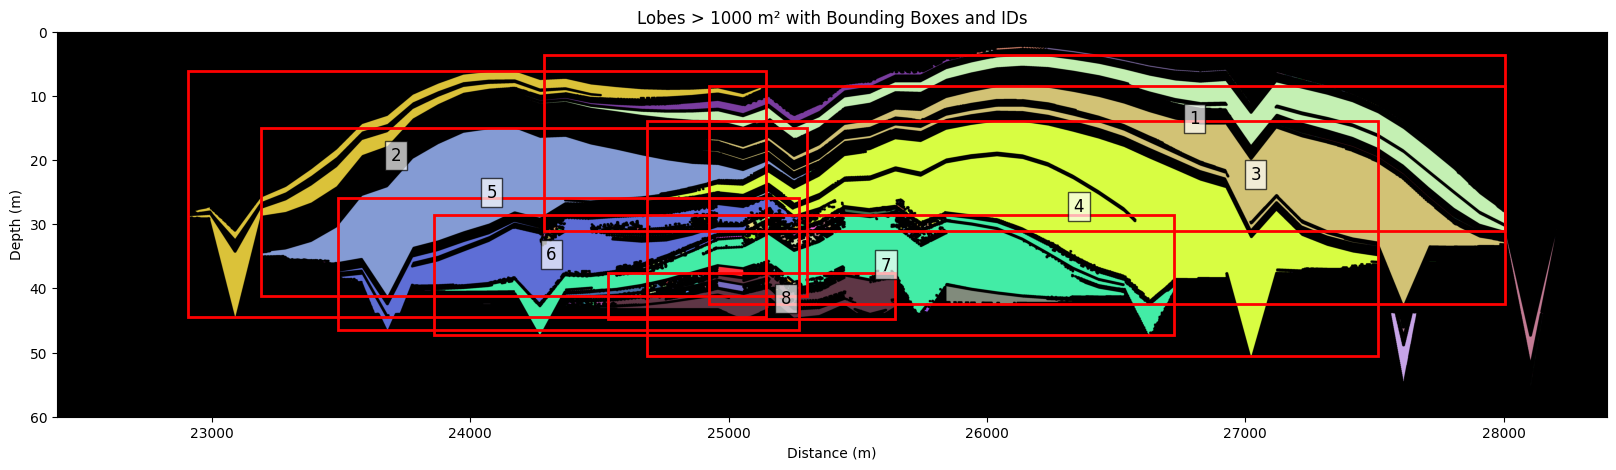

   Lobe ID     Area (m²)    Width (m)  Height (m)  Centroid X (m)  \
0        1   8915.339843  3720.769610   27.429668    26803.520319   
1        2   5174.930636  2237.789837   38.286445    23711.993298   
2        3  15612.675177  3079.921066   34.047315    27039.859214   
3        4  27573.297567  2829.304391   36.675192    26355.558393   
4        5  16244.162880  2114.454859   26.144501    24082.757378   
5        6   7709.218391  1785.397139   20.581841    24314.072306   
6        7  12942.327807  2865.811544   18.721228    25609.829446   
7        8   2719.886393  1111.988160    7.039642    25221.497925   

   Centroid Z (m)  
0       13.494538  
1       19.274855  
2       22.185034  
3       27.226868  
4       25.025332  
5       34.686070  
6       36.349347  
7       41.528319  

Compensation Index (CI): 0.182
Lobe 1 - Average Thickness: 2.40 m
Lobe 2 - Average Thickness: 2.31 m
Lobe 3 - Average Thickness: 5.07 m
Lobe 4 - Average Thickness: 9.75 m
Lobe 5 - Average Thickness

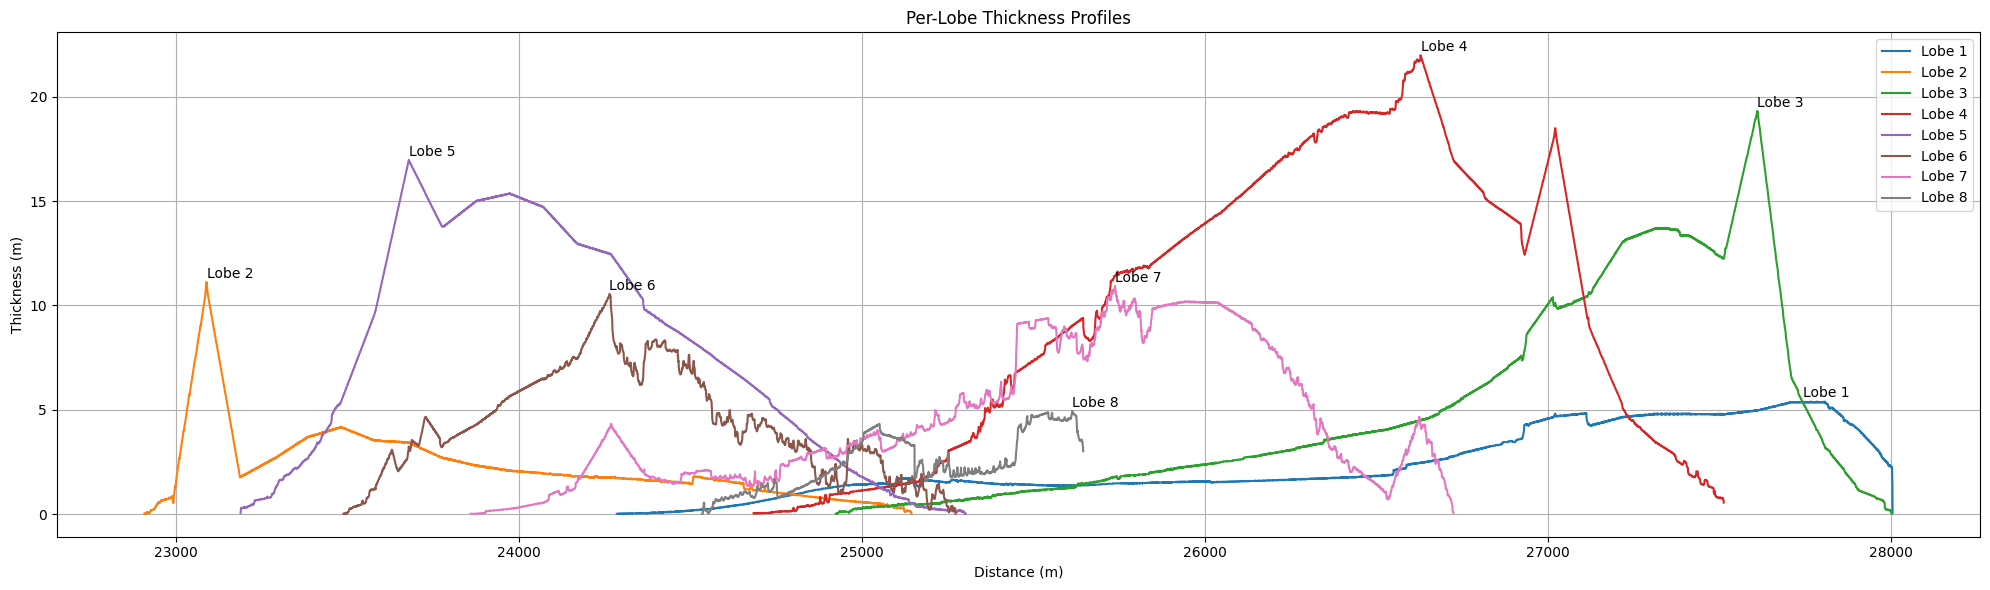

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
from scipy.stats import linregress
import pandas as pd

# --- PARAMETERS ---
real_width_m = 28400 - 22400  # 7000 m
real_height_m = 60            # vertical extent in meters
min_area_m2 = 1000            # minimum area to retain

# --- Load and preprocess image ---
img = cv2.imread("filled_lobes_coloredFrd01.png")  # Ensure this image exists
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = (gray != 0).astype(np.uint8)

# --- Label connected regions ---
labeled, num = label(mask, connectivity=1, return_num=True)
regions = regionprops(labeled)

# --- Get image dimensions and scaling ---
nz, nx = mask.shape
dx = real_width_m / nx
dz = real_height_m / nz

# --- Extract lobe metrics and pixel-wise thickness profiles ---
metrics = []
bbox_regions = []
lobe_thickness_profiles = {}

for i, region in enumerate(regions):
    area_m2 = region.area * dx * dz
    if area_m2 < min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width_m = (maxc - minc) * dx
    height_m = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = 22400 + cx * dx
    cz_m = cz * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area_m2,
        "Width (m)": width_m,
        "Height (m)": height_m,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })

    bbox_regions.append((region, cx_m, cz_m))

    # Pixel-wise thickness profile
    label_mask = (labeled == region.label)
    x_coords = []
    thickness_vals = []

    for c in range(minc, maxc):
        col = label_mask[:, c]
        thick_pix = np.sum(col)
        if thick_pix > 0:
            x_real = 22400 + c * dx
            thickness = thick_pix * dz
            x_coords.append(x_real)
            thickness_vals.append(thickness)

    if len(x_coords) > 0:
        lobe_thickness_profiles[f"Lobe {len(metrics)}"] = (np.array(x_coords), np.array(thickness_vals))

# --- Plot bounding boxes and IDs ---
extent = [22400, 28400, 60, 0]
plt.figure(figsize=(20, 5))
plt.imshow(img_rgb, extent=extent, aspect='auto')
plt.title(f"Lobes > {min_area_m2} m² with Bounding Boxes and IDs")

for idx, (region, cx_m, cz_m) in enumerate(bbox_regions):
    minr, minc, maxr, maxc = region.bbox
    x = 22400 + minc * dx
    y = minr * dz
    w = (maxc - minc) * dx
    h = (maxr - minr) * dz
    rect = Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(idx + 1), color='black', fontsize=12,
             ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black'))

plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# --- Compute Compensation Index from pixel-wise profiles ---
x_common = np.linspace(22400, 28400, 2000)
thickness_grid = []

for x_vals, t_vals in lobe_thickness_profiles.values():
    interp_t = np.interp(x_common, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_thick = np.mean(p)
    if mean_thick == 0:
        continue
    norm_p = p / mean_thick
    sss.append(np.std(norm_p))
    H.append(mean_thick)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CI = -slope
else:
    CI = None

# --- Output and Thickness Plots ---
df = pd.DataFrame(metrics)
print(df)
print(f"\nCompensation Index (CI): {CI:.3f}" if CI is not None else "Not enough lobes to compute CI.")

# --- Plot per-lobe thickness profiles and print average thickness ---
plt.figure(figsize=(20, 6))
for lobe_name, (x_vals, t_vals) in lobe_thickness_profiles.items():
    avg_thickness = np.mean(t_vals)
    print(f"{lobe_name} - Average Thickness: {avg_thickness:.2f} m")
    
    plt.plot(x_vals, t_vals, label=lobe_name)
    idx = np.argmax(t_vals)
    plt.text(x_vals[idx], t_vals[idx] + 0.2, lobe_name, fontsize=10)

plt.title("Per-Lobe Thickness Profiles")
plt.xlabel("Distance (m)")
plt.ylabel("Thickness (m)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [10]:
target_x = 26900  # the horizontal distance you're interested in (in meters)

# Loop through all lobes
for lobe_name, (x_coords, thickness) in lobe_thickness_profiles.items():
    # Find index of closest x coordinate
    idx = np.argmin(np.abs(x_coords - target_x))
    nearest_x = x_coords[idx]
    value = thickness[idx]

    print(f"{lobe_name} | Nearest X: {nearest_x:.2f} m | Thickness: {value:.2f} m")

Lobe 1 | Nearest X: 23584.03 m | Thickness: 0.35 m
Lobe 2 | Nearest X: 26897.67 m | Thickness: 8.82 m
Lobe 3 | Nearest X: 26897.67 m | Thickness: 21.27 m
Lobe 4 | Nearest X: 26897.67 m | Thickness: 1.38 m
Lobe 5 | Nearest X: 26868.55 m | Thickness: 0.35 m


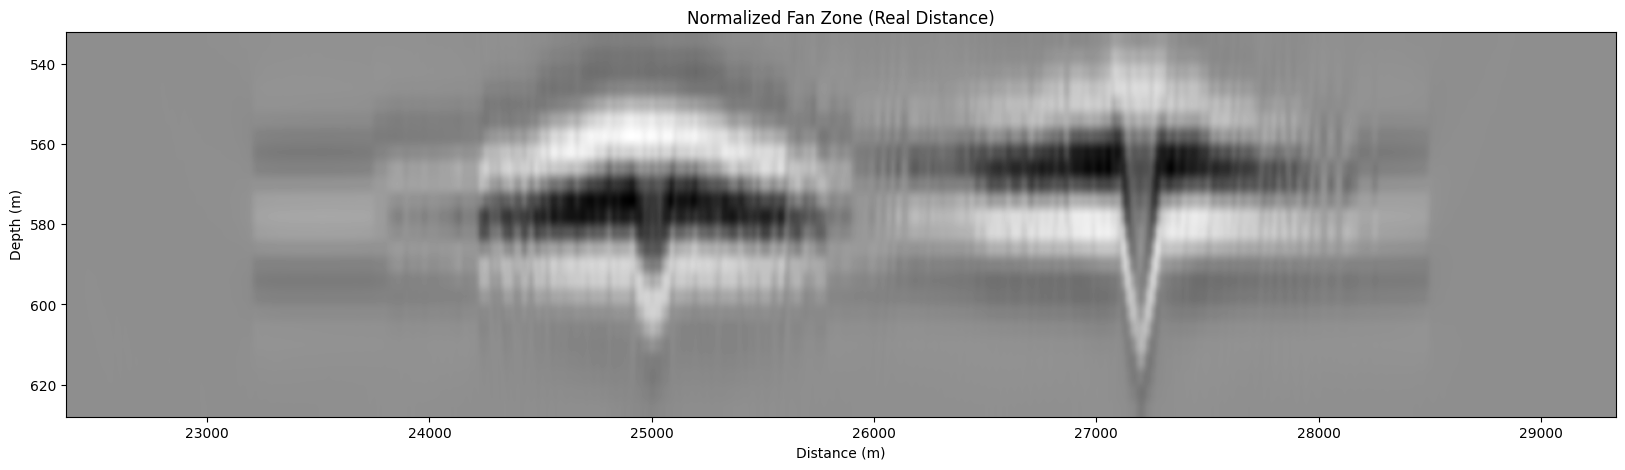

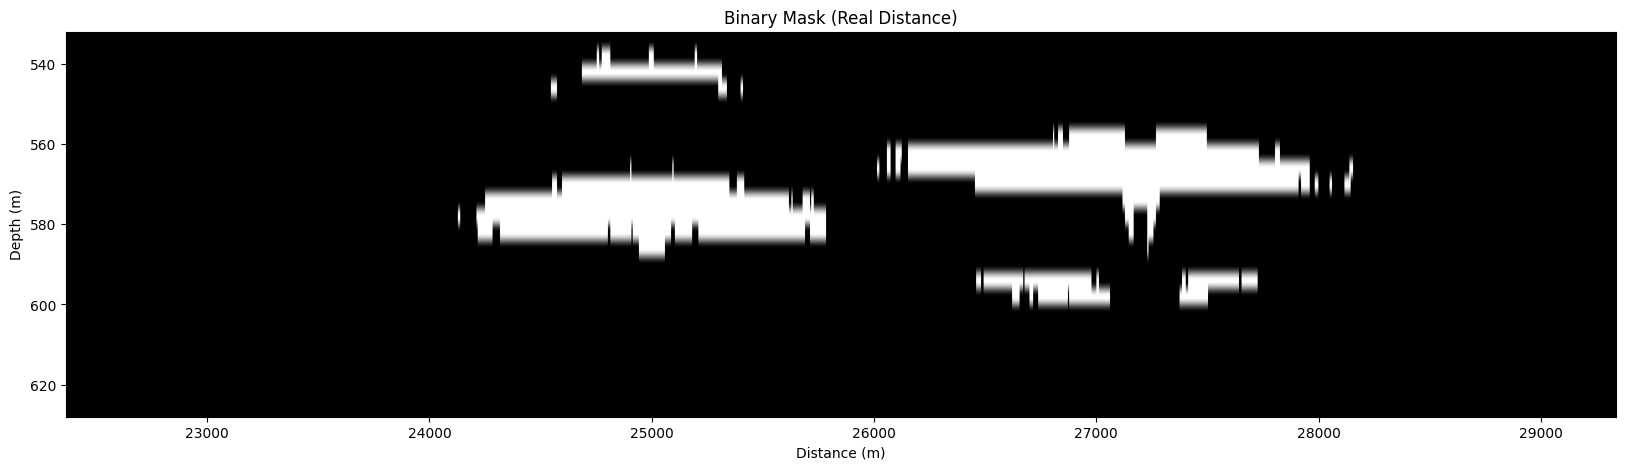

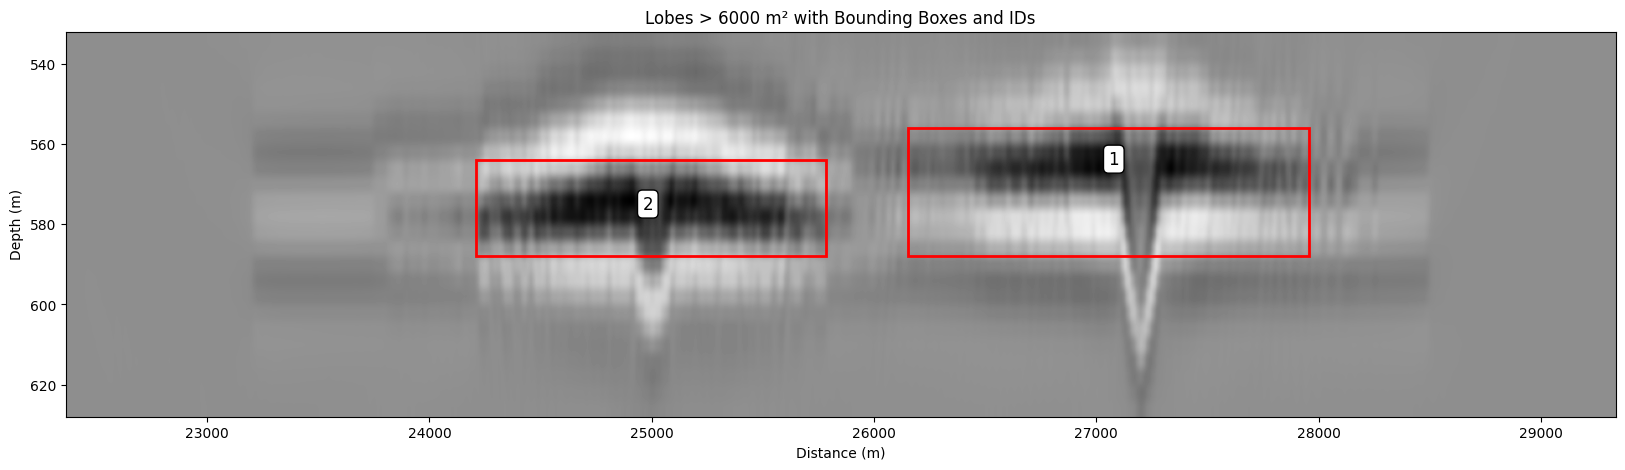

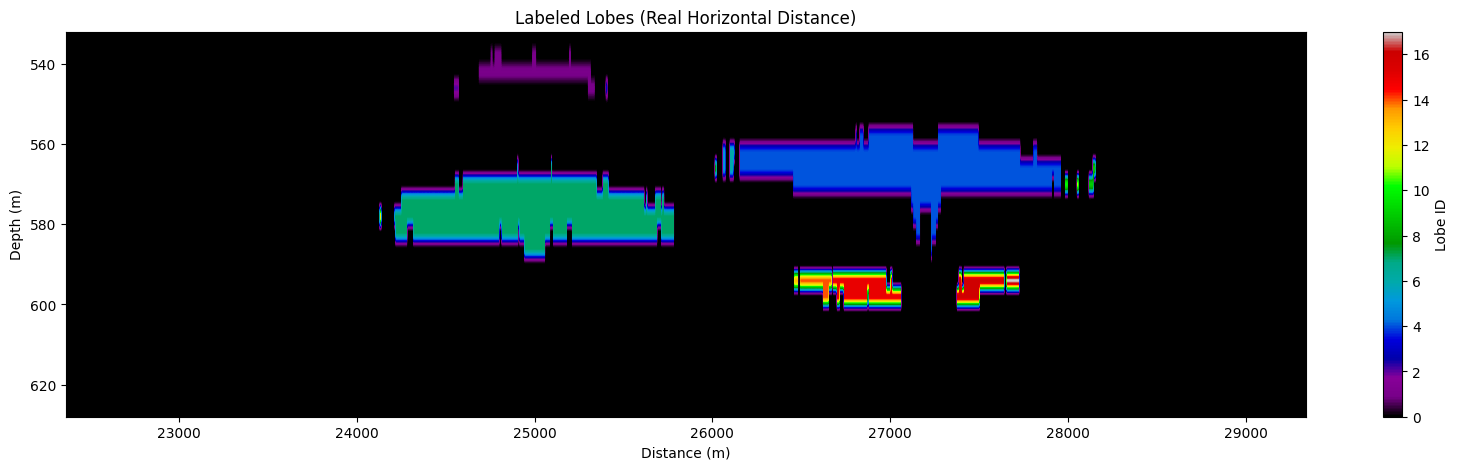

   Lobe ID  Area (m²)    Width (m)  Height (m)  Centroid X (m)  Centroid Z (m)
0        1    16384.0  1807.578947          32    27078.975637      563.773438
1        2    15424.0  1573.263158          24    24982.462110      574.970954

Compensation Index (CI): 0.730
Lobe ID 1 - Average Thickness: 12.64 m


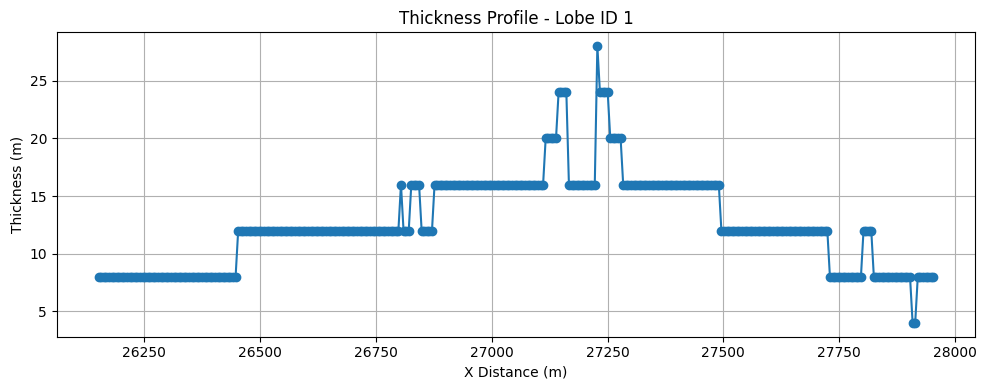

Lobe ID 2 - Average Thickness: 13.67 m


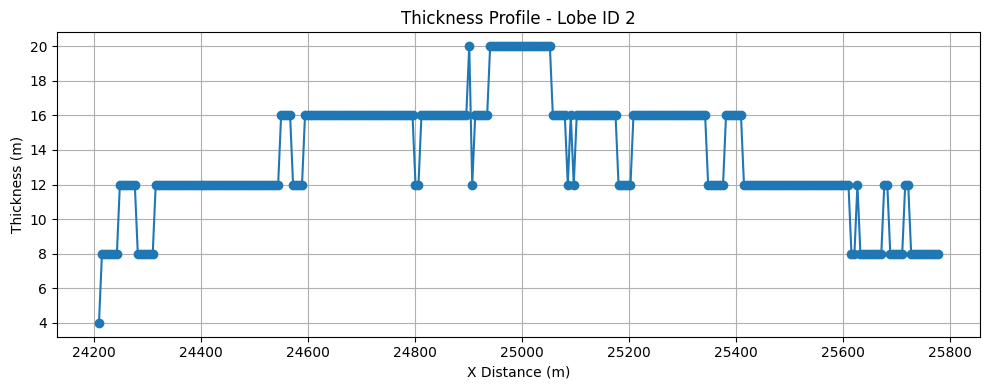

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage.measure import regionprops
from matplotlib.patches import Rectangle
import pandas as pd
from scipy.stats import linregress

# --- PARAMETERS ---
dz = 4
dx = 4
depth_target_m = 580
window_thickness_m = 100
min_area_m2 = 3000

real_fan_start = 23200
real_fan_end = 28500
real_fan_width = real_fan_end - real_fan_start
model_fan_width = 3800
scale_factor = real_fan_width / model_fan_width

# --- LOAD SEISMIC IMAGE ---
full_imageU = np.load("lsrtm_imageStkNLF50Frd20.npy").T

# --- SLICE AROUND DEPTH TARGET ---
center_idx = int(depth_target_m / dz)
half_window = int(window_thickness_m / (2 * dz))
start_idx = max(center_idx - half_window, 0)
end_idx = min(center_idx + half_window, full_imageU.shape[0])
lsrtm_imageU = full_imageU[start_idx:end_idx, :]

# --- REAL DISTANCE SCALING ---
model_overburden_width = lsrtm_imageU.shape[1] * dx
real_overburden_width = model_overburden_width * scale_factor
fan_center = (real_fan_start + real_fan_end) / 2
real_overburden_start = fan_center - real_overburden_width / 2
real_overburden_end = fan_center + real_overburden_width / 2
extent_m = [real_overburden_start, real_overburden_end, end_idx * dz, start_idx * dz]

# --- NORMALIZE & DETECT LOBES ---
norm_fanU = (lsrtm_imageU - lsrtm_imageU.min()) / (lsrtm_imageU.max() - lsrtm_imageU.min())
thresholdU = np.percentile(norm_fanU, 8)
binary_maskU = (norm_fanU < thresholdU).astype(np.uint8)

labeledU, _ = label(binary_maskU)
regionsU = regionprops(labeledU)

# --- METRIC EXTRACTION ---
metrics = []
bbox_regions = []
thickness_profiles = {}

for idx, region in enumerate(regionsU):
    area = region.area * dx * dz
    if area <= min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width = (maxc - minc) * dx * scale_factor
    height = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = real_overburden_start + cx * dx * scale_factor
    cz_m = cz * dz + start_idx * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area,
        "Width (m)": width,
        "Height (m)": height,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })
    bbox_regions.append((region, cx_m, cz_m))

    # --- Per-lobe thickness profile ---
    label_mask = (labeledU == region.label)
    x_coords, thickness_vals = [], []
    for c in range(minc, maxc):
        column = label_mask[:, c]
        thickness = np.sum(column) * dz
        if thickness > 0:
            x_real = real_overburden_start + c * dx * scale_factor
            x_coords.append(x_real)
            thickness_vals.append(thickness)
    thickness_profiles[f"Lobe {idx+1}"] = (np.array(x_coords), np.array(thickness_vals))

df = pd.DataFrame(metrics)

# --- COMPENSATION INDEX FROM PIXEL-WISE THICKNESS ---
x_range = np.linspace(real_overburden_start, real_overburden_end, 2000)
thickness_grid = []

for x_vals, t_vals in thickness_profiles.values():
    interp_t = np.interp(x_range, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_t = np.mean(p)
    if mean_t == 0:
        continue
    norm_p = p / mean_t
    sss.append(np.std(norm_p))
    H.append(mean_t)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CIU = -slope
else:
    CIU = np.nan

# --- PLOTS ---

# 1. Normalized seismic
plt.figure(figsize=(20, 5))
plt.imshow(norm_fanU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Normalized Fan Zone (Real Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 2. Binary mask
plt.figure(figsize=(20, 5))
plt.imshow(binary_maskU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Binary Mask (Real Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 3. Bounding boxes
plt.figure(figsize=(20, 5))
plt.imshow(norm_fanU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Lobes > 6000 m² with Bounding Boxes and IDs")
for lobe_id, (region, cx_m, cz_m) in enumerate(bbox_regions, start=1):
    minr, minc, maxr, maxc = region.bbox
    rect_x = real_overburden_start + minc * dx * scale_factor
    rect_y = start_idx * dz + minr * dz
    rect_width = (maxc - minc) * dx * scale_factor
    rect_height = (maxr - minr) * dz
    rect = Rectangle((rect_x, rect_y), rect_width, rect_height, edgecolor='red',
                     facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(lobe_id), color='black', fontsize=12, ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 4. Labeled lobes
plt.figure(figsize=(20, 5))
plt.imshow(labeledU, cmap='nipy_spectral', aspect='auto', extent=extent_m)
plt.title("Labeled Lobes (Real Horizontal Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.colorbar(label="Lobe ID")
plt.grid(False)
plt.show()

# --- OUTPUT ---
print(df)
print(f"\nCompensation Index (CI): {CIU:.3f}" if not np.isnan(CIU) else "CI could not be computed.")

# --- Plot Thickness Profiles with Lobe ID and Print Average Thickness ---
for i, (lobe_id, (x_vals, thickness_vals)) in enumerate(thickness_profiles.items()):
    lobe_number = df.iloc[i]["Lobe ID"]  # ensure alignment with metrics
    avg_thickness = np.mean(thickness_vals)

    # Print average thickness
    print(f"Lobe ID {int(lobe_number)} - Average Thickness: {avg_thickness:.2f} m")

    # Plot profile
    plt.figure(figsize=(10, 4))
    plt.plot(x_vals, thickness_vals, marker='o')
    plt.title(f"Thickness Profile - Lobe ID {int(lobe_number)}")
    plt.xlabel("X Distance (m)")
    plt.ylabel("Thickness (m)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



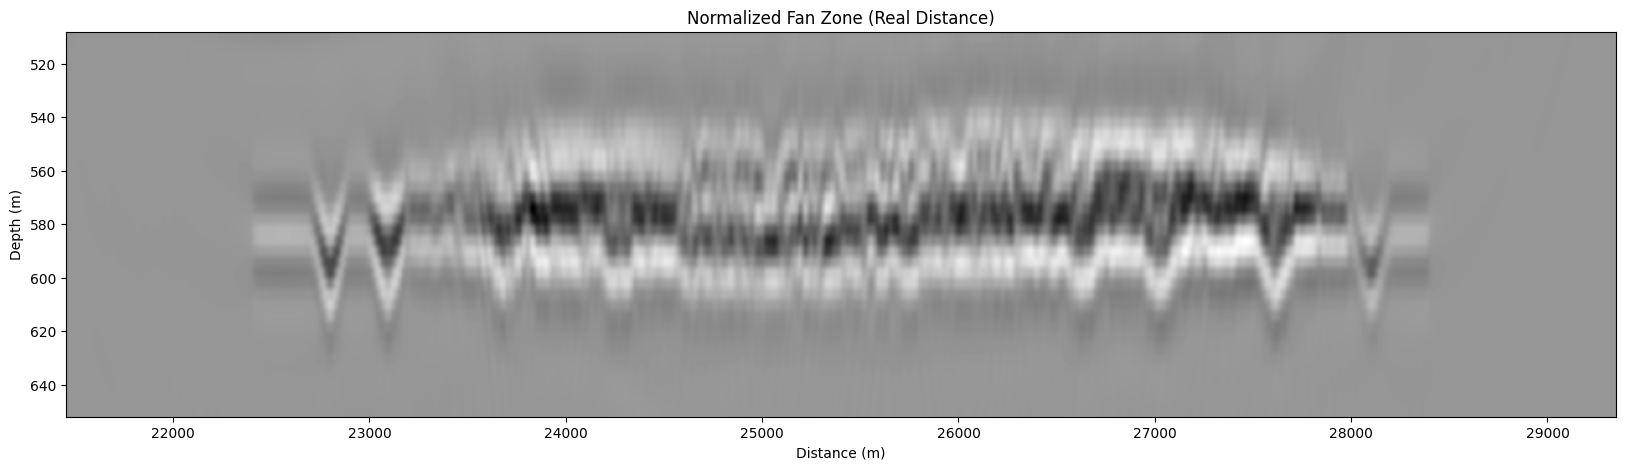

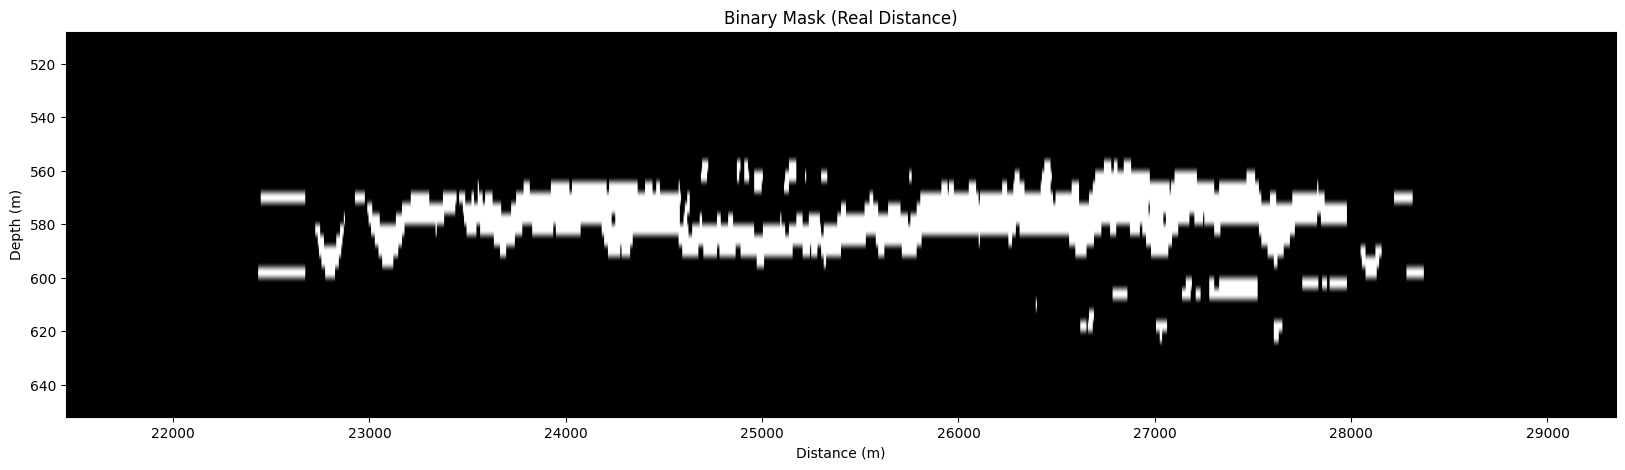

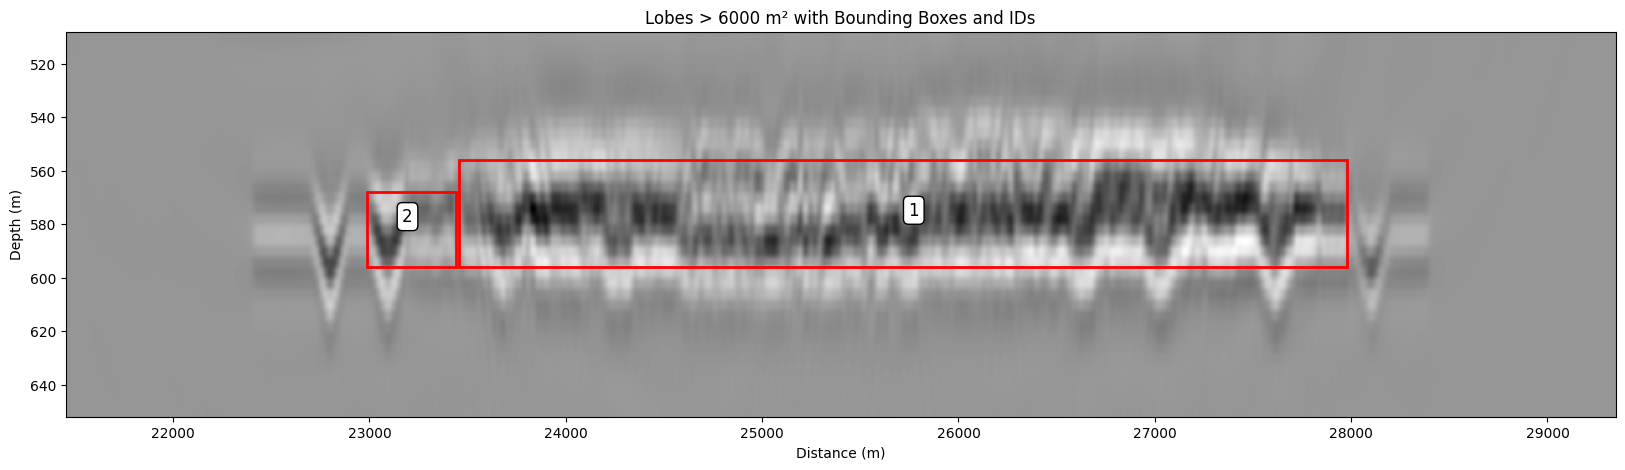

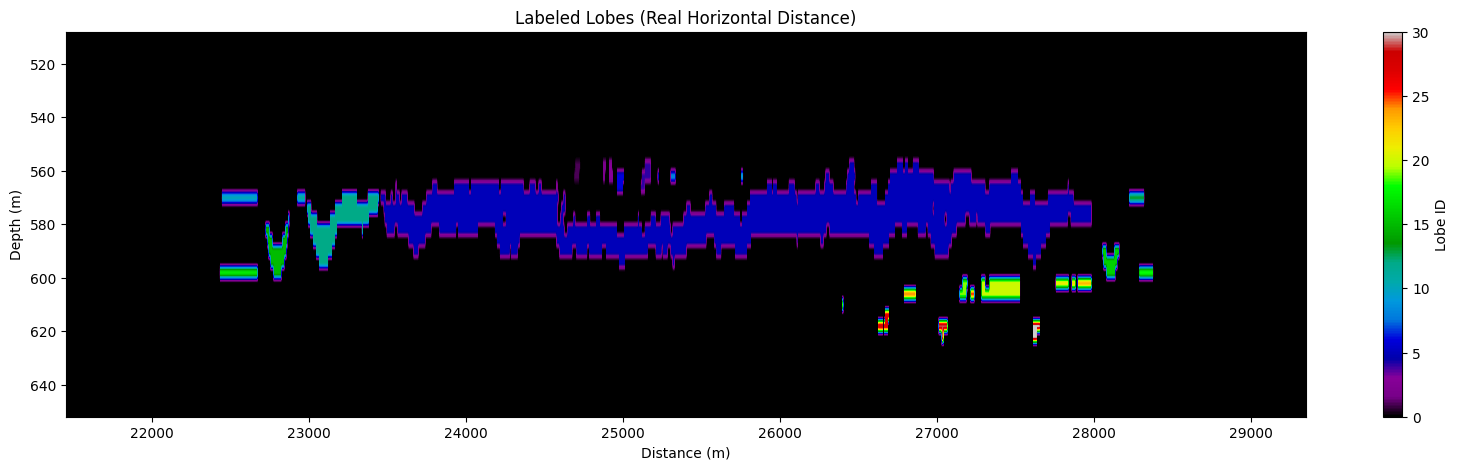

   Lobe ID  Area (m²)    Width (m)  Height (m)  Centroid X (m)  Centroid Z (m)
0        1    47552.0  4522.105263          40    25772.601828      574.776581
1        2     3136.0   454.736842          28    23193.920516      577.163265

Compensation Index (CI): 1.496
Lobe ID 1 - Average Thickness: 16.60 m


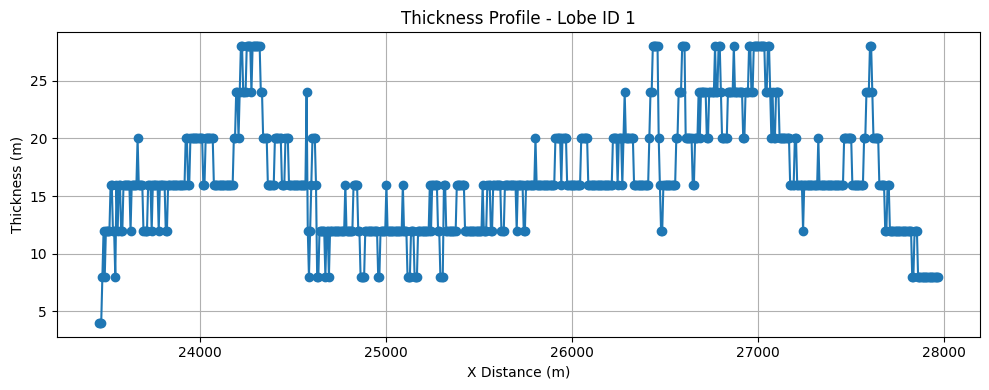

Lobe ID 2 - Average Thickness: 10.89 m


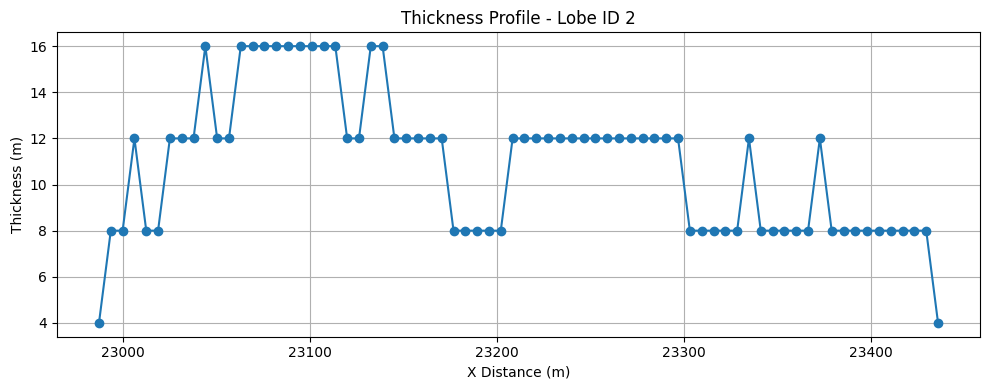

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage.measure import regionprops
from matplotlib.patches import Rectangle
import pandas as pd
from scipy.stats import linregress

# --- PARAMETERS ---
dz = 4
dx = 4
depth_target_m = 580
window_thickness_m = 150
min_area_m2 = 2000

real_fan_start = 22400
real_fan_end = 28400
real_fan_width = real_fan_end - real_fan_start
model_fan_width = 3800
scale_factor = real_fan_width / model_fan_width

# --- LOAD SEISMIC IMAGE ---
full_imageU = np.load("lsrtm_imageStkNLF50Frd01.npy").T

# --- SLICE AROUND DEPTH TARGET ---
center_idx = int(depth_target_m / dz)
half_window = int(window_thickness_m / (2 * dz))
start_idx = max(center_idx - half_window, 0)
end_idx = min(center_idx + half_window, full_imageU.shape[0])
lsrtm_imageU = full_imageU[start_idx:end_idx, :]

# --- REAL DISTANCE SCALING ---
model_overburden_width = lsrtm_imageU.shape[1] * dx
real_overburden_width = model_overburden_width * scale_factor
fan_center = (real_fan_start + real_fan_end) / 2
real_overburden_start = fan_center - real_overburden_width / 2
real_overburden_end = fan_center + real_overburden_width / 2
extent_m = [real_overburden_start, real_overburden_end, end_idx * dz, start_idx * dz]

# --- NORMALIZE & DETECT LOBES ---
norm_fanU = (lsrtm_imageU - lsrtm_imageU.min()) / (lsrtm_imageU.max() - lsrtm_imageU.min())
thresholdU = np.percentile(norm_fanU, 8)
binary_maskU = (norm_fanU < thresholdU).astype(np.uint8)

labeledU, _ = label(binary_maskU)
regionsU = regionprops(labeledU)

# --- METRIC EXTRACTION ---
metrics = []
bbox_regions = []
thickness_profiles = {}

for idx, region in enumerate(regionsU):
    area = region.area * dx * dz
    if area <= min_area_m2:
        continue

    minr, minc, maxr, maxc = region.bbox
    width = (maxc - minc) * dx * scale_factor
    height = (maxr - minr) * dz
    cz, cx = region.centroid
    cx_m = real_overburden_start + cx * dx * scale_factor
    cz_m = cz * dz + start_idx * dz

    metrics.append({
        "Lobe ID": len(metrics) + 1,
        "Area (m²)": area,
        "Width (m)": width,
        "Height (m)": height,
        "Centroid X (m)": cx_m,
        "Centroid Z (m)": cz_m
    })
    bbox_regions.append((region, cx_m, cz_m))

    # --- Per-lobe thickness profile ---
    label_mask = (labeledU == region.label)
    x_coords, thickness_vals = [], []
    for c in range(minc, maxc):
        column = label_mask[:, c]
        thickness = np.sum(column) * dz
        if thickness > 0:
            x_real = real_overburden_start + c * dx * scale_factor
            x_coords.append(x_real)
            thickness_vals.append(thickness)
    thickness_profiles[f"Lobe {idx+1}"] = (np.array(x_coords), np.array(thickness_vals))

df = pd.DataFrame(metrics)

# --- COMPENSATION INDEX FROM PIXEL-WISE THICKNESS ---
x_range = np.linspace(real_overburden_start, real_overburden_end, 2000)
thickness_grid = []

for x_vals, t_vals in thickness_profiles.values():
    interp_t = np.interp(x_range, x_vals, t_vals, left=0, right=0)
    thickness_grid.append(interp_t)

thickness_grid = np.array(thickness_grid)
cumulative = np.cumsum(thickness_grid, axis=0)

H, sss = [], []
for i in range(cumulative.shape[0]):
    p = cumulative[i]
    mean_t = np.mean(p)
    if mean_t == 0:
        continue
    norm_p = p / mean_t
    sss.append(np.std(norm_p))
    H.append(mean_t)

if len(H) >= 2:
    log_H = np.log10(H)
    log_sss = np.log10(sss)
    slope, *_ = linregress(log_H, log_sss)
    CIU = -slope
else:
    CIU = np.nan

# --- PLOTS ---

# 1. Normalized seismic
plt.figure(figsize=(20, 5))
plt.imshow(norm_fanU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Normalized Fan Zone (Real Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 2. Binary mask
plt.figure(figsize=(20, 5))
plt.imshow(binary_maskU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Binary Mask (Real Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 3. Bounding boxes
plt.figure(figsize=(20, 5))
plt.imshow(norm_fanU, cmap='gray', aspect='auto', extent=extent_m)
plt.title("Lobes > 6000 m² with Bounding Boxes and IDs")
for lobe_id, (region, cx_m, cz_m) in enumerate(bbox_regions, start=1):
    minr, minc, maxr, maxc = region.bbox
    rect_x = real_overburden_start + minc * dx * scale_factor
    rect_y = start_idx * dz + minr * dz
    rect_width = (maxc - minc) * dx * scale_factor
    rect_height = (maxr - minr) * dz
    rect = Rectangle((rect_x, rect_y), rect_width, rect_height, edgecolor='red',
                     facecolor='none', linewidth=2)
    plt.gca().add_patch(rect)
    plt.text(cx_m, cz_m, str(lobe_id), color='black', fontsize=12, ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.grid(False)
plt.show()

# 4. Labeled lobes
plt.figure(figsize=(20, 5))
plt.imshow(labeledU, cmap='nipy_spectral', aspect='auto', extent=extent_m)
plt.title("Labeled Lobes (Real Horizontal Distance)")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (m)")
plt.colorbar(label="Lobe ID")
plt.grid(False)
plt.show()

# --- OUTPUT ---
print(df)
print(f"\nCompensation Index (CI): {CIU:.3f}" if not np.isnan(CIU) else "CI could not be computed.")

# --- Plot Thickness Profiles with Lobe ID and Print Average Thickness ---
for i, (lobe_id, (x_vals, thickness_vals)) in enumerate(thickness_profiles.items()):
    lobe_number = df.iloc[i]["Lobe ID"]  # ensure alignment with metrics
    avg_thickness = np.mean(thickness_vals)

    # Print average thickness
    print(f"Lobe ID {int(lobe_number)} - Average Thickness: {avg_thickness:.2f} m")

    # Plot profile
    plt.figure(figsize=(10, 4))
    plt.plot(x_vals, thickness_vals, marker='o')
    plt.title(f"Thickness Profile - Lobe ID {int(lobe_number)}")
    plt.xlabel("X Distance (m)")
    plt.ylabel("Thickness (m)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

